# Nepal Earthquake Building Damage Prediction
## Predicting Severe Damage in Ramechhap District (2015 Gorkha Earthquake)

**Overview**  
The 2015 Gorkha earthquake in Nepal was one of the most devastating disasters in the country’s modern history, destroying or damaging hundreds of thousands of buildings and claiming nearly 9,000 lives. 
This project uses real post-disaster survey data collected by Kathmandu Living Labs and Nepal’s Central Bureau of Statistics to build a classification model that predicts whether a building suffered severe damage.
By focusing on Ramechhap district (one of the heavily affected areas), the model can help governments, NGOs, and insurance companies prioritize retrofitting, allocate reconstruction funds more fairly, and improve future building codes in earthquake-prone regions.

**Data source:** Raw train_values.csv + train_labels.csv from DrivenData (public competition data, ~260k buildings) - https://www.drivendata.org/competitions/57/nepal-earthquake/data/.

**ETL step:** a local SQLite relational database from scratch (two tables: building_features and building_damage) using Python + sqlite3.

**SQL skills:** Joins, schema exploration, filtered queries.

**Wrangling:** Leakage audit (none in raw data), multicollinearity check, high-cardinality handling, binary target engineering (severe_damage = damage_grade 3).

**Model:** Logistic Regression + OneHotEncoder pipeline (scikit-learn).

**Evaluation:** Accuracy + odds-ratio interpretation (feature importance for non-technical stakeholders).

**Ethics:** Dedicated section on fairness, bias, and real-world deployment risks.

---

In [2]:
# Imports
import sqlite3
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

warnings.simplefilter(action="ignore", category=FutureWarning)
sns.set_style("whitegrid")
%matplotlib inline

## 1: Building SQLite Database from Raw CSVs (ETL)

In [3]:
# Create and populate the SQLite database
conn = sqlite3.connect("nepal_earthquake.db")

# Load raw CSVs (assumes files are in the same folder as the notebook)
train_values = pd.read_csv("train_values.csv")
train_labels = pd.read_csv("train_labels.csv")

# Create tables
train_values.to_sql("building_features", conn, if_exists="replace", index=False)
train_labels.to_sql("building_damage", conn, if_exists="replace", index=False)

print("Database created successfully!")
print("Tables:", pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn))

Database created successfully!
Tables:                 name
0  building_features
1    building_damage


In [7]:
# Explore schema 
# List all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in the database:")
print(tables)

# Preview building_features
print("\nFirst 5 rows of building_features:")
print(pd.read_sql("SELECT * FROM building_features LIMIT 5;", conn))

# Preview building_damage
print("\nFirst 5 rows of building_damage:")
print(pd.read_sql("SELECT * FROM building_damage LIMIT 5;", conn))

conn.close()

Tables in the database:
                name
0  building_features
1    building_damage

First 5 rows of building_features:
   building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
0       802906               6             487           12198   
1        28830               8             900            2812   
2        94947              21             363            8973   
3       590882              22             418           10694   
4       201944              11             131            1488   

   count_floors_pre_eq  age  area_percentage  height_percentage  \
0                    2   30                6                  5   
1                    2   10                8                  7   
2                    2   10                5                  5   
3                    2   10                6                  5   
4                    3   30                8                  9   

  land_surface_condition foundation_type  ... has_secondary_use_agriculture  

## 2: Data Wrangling with SQL + Pandas

In [8]:
# Create wrangle function
def wrangle(db_path):
    conn = sqlite3.connect(db_path)
    
    query = """
        SELECT f.*, d.damage_grade
        FROM building_features f
        JOIN building_damage d ON f.building_id = d.building_id
    """
    df = pd.read_sql(query, conn, index_col="building_id")
        
    # Create binary target (DrivenData uses 1-2-3 scale; 3 = severe)
    df["severe_damage"] = (df["damage_grade"] == 3).astype(int)
    df.drop(columns=["damage_grade"], inplace=True)
    
    # Drop multicollinear feature
    df.drop(columns=["count_floors_pre_eq"], inplace=True)
    
    return df

df = wrangle("nepal_earthquake.db")
print(df.shape)
df.head()

(260601, 38)


,geo_level_1_id,geo_level_2_id,geo_level_3_id,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,severe_damage
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,30,6,5,t,r,n,f,...,0,0,0,0,0,0,0,0,0,1
28830,8,900,2812,10,8,7,o,r,n,x,...,0,0,0,0,0,0,0,0,0,0
94947,21,363,8973,10,5,5,t,r,n,f,...,0,0,0,0,0,0,0,0,0,1
590882,22,418,10694,10,6,5,t,r,n,f,...,0,0,0,0,0,0,0,0,0,0
201944,11,131,1488,30,8,9,t,r,n,f,...,0,0,0,0,0,0,0,0,0,1


## 3: Exploratory Data Analysis

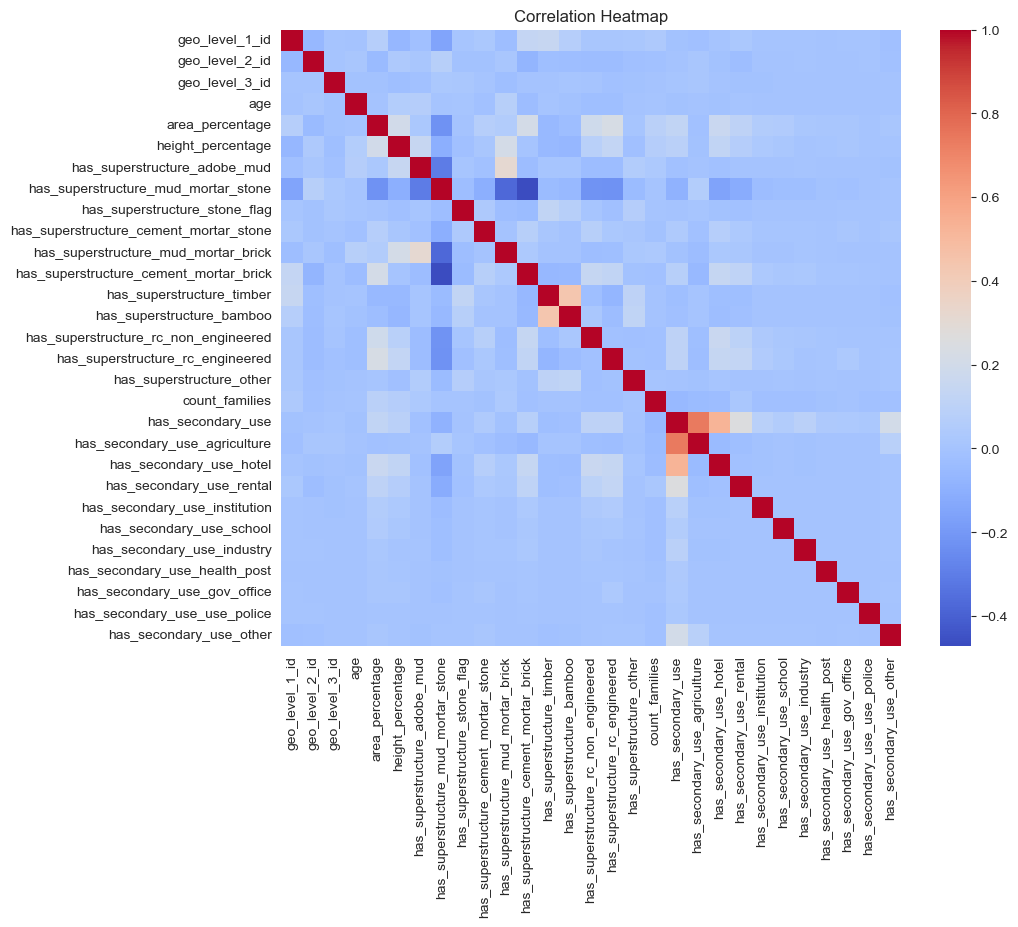

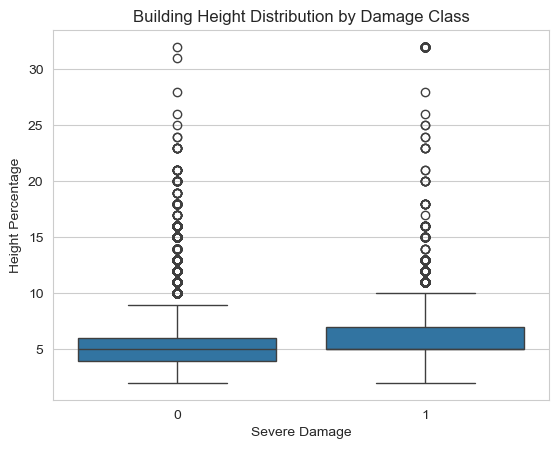

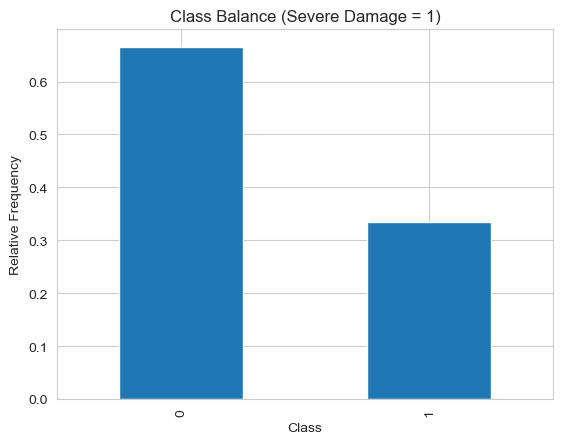

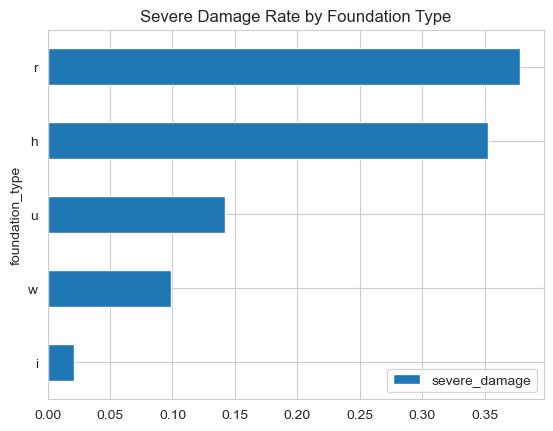

In [9]:
# Correlation heatmap (numeric features only)
numeric_cols = df.select_dtypes("number").drop(columns="severe_damage").columns
correlation = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplot: height vs severe damage
sns.boxplot(x="severe_damage", y="height_percentage", data=df)
plt.xlabel("Severe Damage")
plt.ylabel("Height Percentage")
plt.title("Building Height Distribution by Damage Class")
plt.show()

# Class balance
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar", xlabel="Class", ylabel="Relative Frequency",
    title="Class Balance (Severe Damage = 1)"
)
plt.show()

# Foundation type pivot (example categorical insight)
foundation_pivot = pd.pivot_table(
    df, index="foundation_type", values="severe_damage", aggfunc="mean"
).sort_values(by="severe_damage")
foundation_pivot.plot(kind="barh")
plt.title("Severe Damage Rate by Foundation Type")
plt.show()

The dataset exhibits clear class imbalance, with severe damage (grade 3) representing the minority class. This is realistic for earthquake damage data, where most buildings suffer only light to moderate damage while a smaller portion collapses or becomes uninhabitable. Building height (`height_percentage`) emerges as a strong signal, with taller structures showing higher median values in the severe damage group - consistent with increased seismic vulnerability due to higher center of mass and greater resonance effects during ground shaking.

The pivot table and bar chart for **foundation_type** reveal even more actionable insights. Severe damage rates vary dramatically across foundation categories (labeled as `i`, `w`, `u`, `h`, and `r` in the data):

- Foundation type `r` has the highest severe damage rate (clearly the tallest bar), followed closely by `h`.
- Types `u` and `w` show moderate risk.
- Foundation type `i` has by far the lowest severe damage rate (very short bar).